In this notebook, we will create a compilation of systems in two ways: we will combine all data we have so far and obtain $\gamma_{\mathrm{PPN}}$ using all systems (with $\sigma_v$ and $\sigma_0$), and also obtain the same quantity with systems that has some previous cuts.

In [1]:
# !pip install matplotlib-venn venn

In [2]:
import getdist
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rings2cosmo
from getdist import MCSamples, plots
from matplotlib_venn import venn3_circles, venn3_unweighted
from venn import venn

pd.set_option("display.max_colwidth", None)

%matplotlib inline

In [3]:
mpl.rcParams.update(
    {
        "font.size": 28,
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": True,
    }
)

# Data used for plotting and `rings2cosmo` script to obtain gamma_PPN:
colors = plt.cm.turbo(np.linspace(0.1, 0.9, 20))
labels = [r"\alpha", r"\beta", r"\delta", r"\gamma"]

In [4]:
# Loading the data
Data = pd.read_csv("01_LaStBeRu_cosmo_ground.csv")
Data["in_lastberu_cosmo_ground"] = True
Cao_Data = pd.read_csv("03_Cao_et_al._(2015)_Data.csv")
Chen_Data = pd.read_csv("03_Chen_et_al._(2019)_Data.csv")
Chen_Data.loc[Chen_Data[Chen_Data.JNAME.isna()].index[0], "JNAME"] = "SL2SJ020524−93023"
(
    len(Data),
    len(Cao_Data),
    len(Chen_Data),
    np.unique(np.hstack([Data.JNAME, Cao_Data.JNAME, Chen_Data.JNAME])).shape[0],
)

(132, 118, 161, 206)

# Data to be combined

/home/renan/miniforge3/lib/python3.12/site-packages/matplotlib_venn/_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


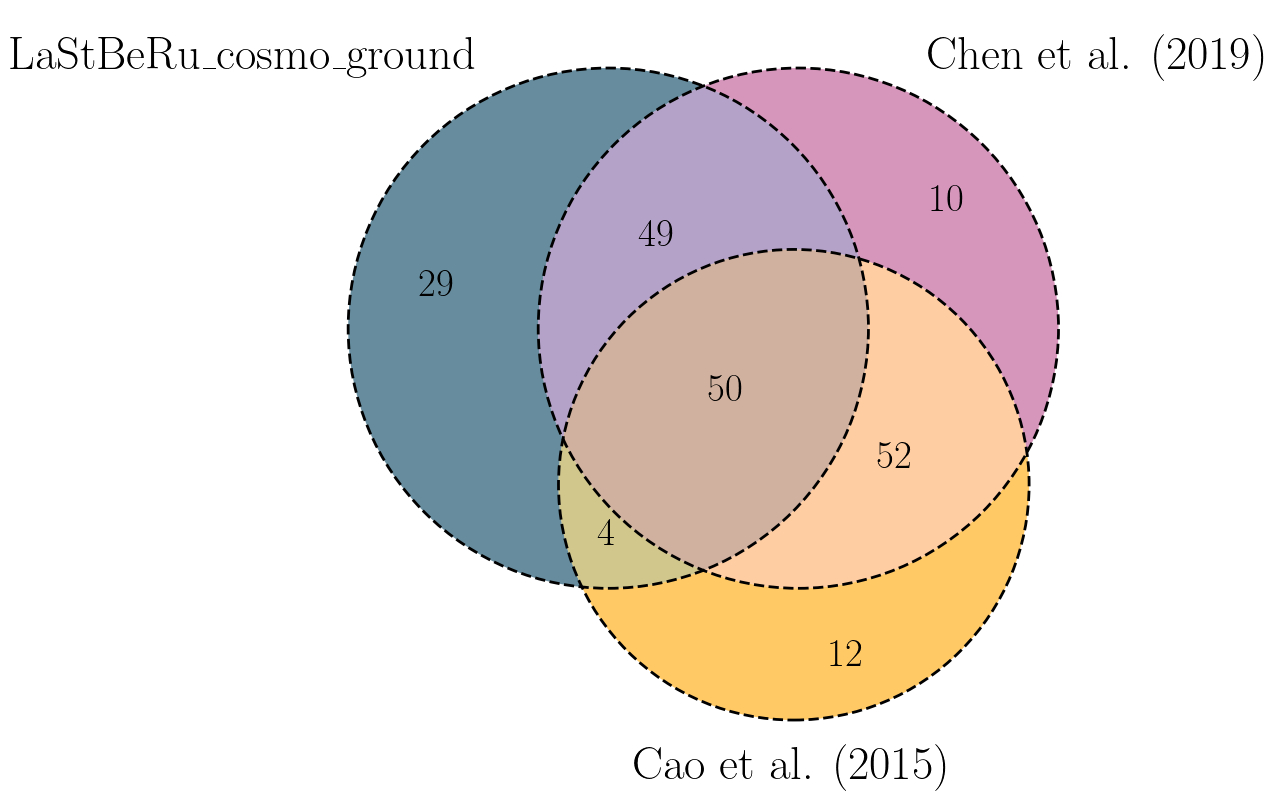

In [5]:
set1 = set(Data["JNAME"].astype("str").values)
set2 = set(Chen_Data["JNAME"].astype("str").values)
set3 = set(Cao_Data["JNAME"].astype("str").values)

fig = plt.figure(figsize=(15, 10))
venn3_unweighted(
    [set1, set2, set3],
    (r"$\mathrm{LaStBeRu\_cosmo\_ground}$", "Chen et al. (2019)", "Cao et al. (2015)"),
    alpha=0.6,
    subset_areas=(4, 2, 3, 2, 1, 3, 3),  # Log scale
    # 103,10,49,12,4,52,50
    set_colors=("#003f5c", "#bc5090", "#ffa600"),
)

venn3_circles(
    subsets=(4, 2, 3, 2, 1, 3, 3), linestyle="dashed", linewidth=2, color="black"
)
# plt.savefig("graphics/venn.png", dpi=150)
plt.show()

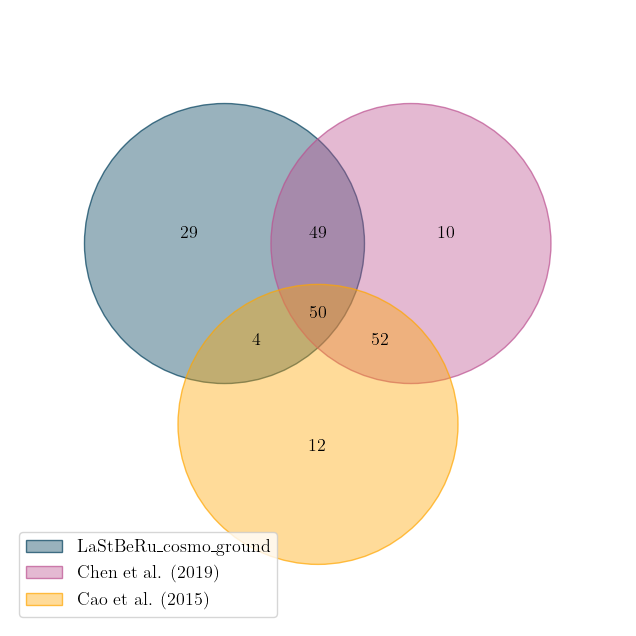

In [6]:
jnames = {
    r"$\mathrm{LaStBeRu\_cosmo\_ground}$": set(Data["JNAME"].values),
    "Chen et al. (2019)": set(Chen_Data["JNAME"].values),
    "Cao et al. (2015)": set(Cao_Data["JNAME"].values),
}
venn(jnames, cmap=["#003f5c", "#bc5090", "#ffa600"], legend_loc="lower left")
# plt.savefig('graphics/venn.png', dpi=150)
plt.show()

In [7]:
(
    len(Data),
    len(Chen_Data.query("~JNAME.isin(@Data.JNAME)")),
    len(Cao_Data.query("~JNAME.isin(@Chen_Data.JNAME) and ~JNAME.isin(@Data.JNAME)")),
)

(132, 62, 12)

In [8]:
Combined_Data = pd.concat(
    [
        Data,
        Chen_Data.query("~JNAME.isin(@Data.JNAME)"),
        Cao_Data.query("~JNAME.isin(@Chen_Data.JNAME) and ~JNAME.isin(@Data.JNAME)"),
    ]
).reset_index(drop=True)
Combined_Data["Original_ID"] = np.hstack(
    (
        Data.JNAME,
        Chen_Data.query("~JNAME.isin(@Data.JNAME)").Chen_Name,
        Cao_Data.query(
            "~JNAME.isin(@Chen_Data.JNAME) and ~JNAME.isin(@Data.JNAME)"
        ).Cao_Name,
    )
)
Combined_Data["Reference"] = np.hstack(
    (
        np.repeat("LaStBeRu_cosmo_ground", len(Data)),
        np.repeat(
            "Chen et al. (2019)", len(Chen_Data.query("~JNAME.isin(@Data.JNAME)"))
        ),
        np.repeat(
            "Cao et al. (2015)",
            len(
                Cao_Data.query(
                    "~JNAME.isin(@Chen_Data.JNAME) and ~JNAME.isin(@Data.JNAME)"
                )
            ),
        ),
    )
)
len(Combined_Data), len(Combined_Data.JNAME.unique())

(206, 206)

In [9]:
Combined_Data["in_lastberu_cosmo_ground"] = Combined_Data.JNAME.isin(Data.JNAME)
Combined_Data["in_cao_2015"] = Combined_Data.JNAME.isin(Cao_Data.JNAME)
Combined_Data["in_cao_2017"] = Combined_Data.JNAME.isin(
    Cao_Data.query("in_cao_2017==True").JNAME
)
Combined_Data["in_chen_2019"] = Combined_Data.JNAME.isin(Chen_Data.JNAME)
Combined_Data["in_liu_2022"] = Combined_Data.JNAME.isin(
    Chen_Data.query("in_liu_2022==True").JNAME
)

In [10]:
@np.vectorize
def get_data(x, y, z):
    data = np.array([x, y, z])
    data = data[~np.isnan(data)]
    if len(data) > 2:
        return print("Bug"), data
    else:
        return data[0]


Combined_Data["theta_E"] = get_data(
    Combined_Data["theta_E"],
    Combined_Data["Cao_theta_E"],
    Combined_Data["Chen_theta_E"],
)
Combined_Data["theta_E_rad"] = get_data(
    Combined_Data["theta_E_rad"],
    Combined_Data["Cao_theta_E_rad"],
    Combined_Data["Chen_theta_E_rad"],
)
Combined_Data["theta_ap"] = get_data(
    Combined_Data["theta_ap"],
    Combined_Data["Cao_theta_ap"],
    Combined_Data["Chen_theta_ap"],
)
Combined_Data["theta_ap_rad"] = get_data(
    Combined_Data["theta_ap_rad"],
    Combined_Data["Cao_theta_ap_rad"],
    Combined_Data["Chen_theta_ap_rad"],
)
Combined_Data["velDisp"] = get_data(
    Combined_Data["velDisp"],
    Combined_Data["Cao_velDisp"],
    Combined_Data["Chen_velDisp"],
)
Combined_Data["velDispErr"] = get_data(
    Combined_Data["velDispErr"],
    Combined_Data["Cao_velDispErr"],
    Combined_Data["Chen_velDispErr"],
)
Combined_Data["velDisp0"] = get_data(
    Combined_Data["velDisp0_petro"],
    Combined_Data["Cao_velDisp0"],
    Combined_Data["Chen_velDisp0"],
)
Combined_Data["velDisp0Err"] = get_data(
    Combined_Data["velDisp0Err_petro"],
    Combined_Data["Cao_velDisp0Err"],
    Combined_Data["Chen_velDisp0Err"],
)
Combined_Data["Seeing"] = get_data(
    Combined_Data["seeing50"],
    Combined_Data["Cao_Seeing_atm"],
    Combined_Data["Chen_Seeing_atm"],
)
Combined_Data["Seeing_rad"] = get_data(
    Combined_Data["seeing50_rad"],
    Combined_Data["Cao_Seeing_atm_rad"],
    Combined_Data["Chen_Seeing_atm_rad"],
)
Combined_Data["z_L"] = get_data(
    Combined_Data["z_L"], Combined_Data["Cao_z_L"], Combined_Data["Chen_z_L"]
)
Combined_Data["z_S"] = get_data(
    Combined_Data["z_S"], Combined_Data["Cao_z_S"], Combined_Data["Chen_z_S"]
)
Combined_Data["theta_Eff"] = get_data(
    Combined_Data["petror50_r"],
    Combined_Data["Cao_theta_eff"],
    Combined_Data["Chen_theta_eff"],
)
Combined_Data["theta_Eff_rad"] = get_data(
    Combined_Data["petror50_r_rad"],
    Combined_Data["Cao_theta_eff_rad"],
    Combined_Data["Chen_theta_eff_rad"],
)

Combined_Data = Combined_Data[
    [
        "JNAME",
        "Original_ID",
        "z_L",
        "z_S",
        "velDisp",
        "velDispErr",
        "velDisp0",
        "velDisp0Err",
        "theta_E",
        "theta_ap",
        "theta_Eff",
        "Seeing",
        "theta_E_rad",
        "theta_ap_rad",
        "theta_Eff_rad",
        "Seeing_rad",
        "Reference",
        "in_cao_2015",
        "in_cao_2017",
        "in_chen_2019",
        "in_liu_2022",
        "in_lastberu_cosmo_ground",
    ]
]

Combined_Data = Combined_Data.fillna(False).convert_dtypes()
Combined_Data.head()

,JNAME,Original_ID,z_L,z_S,velDisp,velDispErr,velDisp0,velDisp0Err,theta_E,theta_ap,...,theta_E_rad,theta_ap_rad,theta_Eff_rad,Seeing_rad,Reference,in_cao_2015,in_cao_2017,in_chen_2019,in_liu_2022,in_lastberu_cosmo_ground
0,J002240.9+143110.1,J002240.9+143110.1,0.380506,2.73,396.9931,55.420086,401.293768,57.340201,2.91,1.5,...,0.000014,0.000007,0.000012,0.000007,LaStBeRu_cosmo_ground,False,False,False,False,True
1,J002907.8-005550.5,J002907.8-005550.5,0.227043,0.931,201.65935,18.19063,205.369169,19.612457,0.96,1.5,...,0.000005,0.000007,0.000011,0.000009,LaStBeRu_cosmo_ground,True,True,True,True,True
2,J002927.4+254401.8,J002927.4+254401.8,0.586881,2.45,212.64645,51.071056,217.632298,52.735034,0.81,1.0,...,0.000004,0.000005,0.000007,0.000008,LaStBeRu_cosmo_ground,False,False,True,False,True
3,J004402.9+011312.6,J004402.9+011312.6,0.119582,0.196,254.28107,12.22925,260.6036,15.114514,0.79,1.5,...,0.000004,0.000007,0.00001,0.000008,LaStBeRu_cosmo_ground,True,True,True,True,True
4,J014356.6-100633.7,J014356.6-100633.7,0.220969,1.1046,207.81186,18.66151,211.578823,20.121941,1.23,1.5,...,0.000006,0.000007,0.000011,0.00001,LaStBeRu_cosmo_ground,False,False,True,True,True


In [11]:
Combined_Data.to_csv("05_Combined_Data.csv", index=False)